# Continuous pretraining of Prithvi MAE: background-prefetched input

This notebook continues masked-autoencoder pretraining from the existing Prithvi MAE checkpoint using the rolling four-year TFRecord dataset created by `Pre_process_continous_pretraining_data_clean.ipynb`.

Each stored record contains all available years for one product and location. The loader selects consecutive four-year windows while streaming the compressed shards. For every sample, two random timesteps are fully hidden and 70% of spatial patches are hidden in each of the other two timesteps. The unmasked sequence remains the reconstruction target.

The workflow includes:

- checkpoint-shape auditing and compatible pretrained-weight loading;
- bounded background prefetching from 64 train and 16 validation shards;
- mixed-precision training with gradient accumulation and resumable checkpoints;
- exact temporal-spatial token masking inside the Prithvi encoder;
- a two-row visualization before training: unmasked and masked input;
- a three-row visualization after training: masked input, expected output, and MAE prediction.

## Environment

Use the same `ml-env2` kernel as the segmentation notebook. The install command is intentionally commented out so opening the notebook does not alter a working environment.

In [ ]:
# Run only if the kernel is missing these packages, then restart it.
# %pip install "numpy<2" "terratorch==1.0" "tensorflow==2.10.1" tqdm matplotlib

In [1]:
import importlib.util
import itertools
import json
import os
import queue
import random
import threading
import time
import traceback
import types
from collections import defaultdict
from contextlib import contextmanager
from pathlib import Path

# Rasterio 1.4 bundles the PROJ database required by TerraTorch/TorchGeo.
# Select it before importing packages that may initialize GDAL/PROJ.
rasterio_spec = importlib.util.find_spec("rasterio")
if rasterio_spec is None or rasterio_spec.origin is None:
    raise ImportError("Rasterio is required by TerraTorch")
rasterio_proj_data = Path(rasterio_spec.origin).parent / "proj_data"
if not (rasterio_proj_data / "proj.db").exists():
    raise FileNotFoundError(f"Rasterio PROJ database not found: {rasterio_proj_data}")
os.environ["PROJ_DATA"] = str(rasterio_proj_data)
os.environ["PROJ_LIB"] = str(rasterio_proj_data)

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import torch
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import (
    DataLoader,
    IterableDataset,
    default_collate,
    get_worker_info,
)
from tqdm.auto import tqdm

from terratorch.models.backbones.prithvi_mae import PrithviMAE

print("PROJ data:", rasterio_proj_data)

# TensorFlow parses TFRecords only. Preserve the GPU for PyTorch.
try:
    tf.config.set_visible_devices([], "GPU")
    tf.config.threading.set_intra_op_parallelism_threads(1)
    tf.config.threading.set_inter_op_parallelism_threads(1)
except RuntimeError as error:
    print("TensorFlow was already initialized:", error)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)
print("Device:", device)
if torch.cuda.is_available():
    properties = torch.cuda.get_device_properties(0)
    print("GPU:", properties.name)
    print("GPU memory: {:.1f} GiB".format(properties.total_memory / 2**30))

c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJ data: c:\Users\emmanuelasare\AppData\Local\anaconda3\envs\ml-env2\lib\site-packages\rasterio\proj_data
PyTorch: 2.11.0+cu126
TensorFlow: 2.10.1
Device: cuda
GPU: NVIDIA GeForce RTX 3090
GPU memory: 24.0 GiB


## Configuration

The supplied checkpoint is the large Prithvi MAE configuration: encoder width 1024, 24 encoder blocks, and an eight-block decoder. With two fully masked timesteps and 70% spatial masking on the other two, 118 of 784 tokens remain visible and the effective overall mask ratio is approximately 85%.

`TRAIN_WINDOW_MODE="random"` selects one valid four-year window per stored record each epoch. This changes the selected years between epochs without expanding all 435,540 windows into memory. Validation uses all windows but is bounded by `MAX_VAL_BATCHES`.

In [3]:
DATA_ROOT = Path(
    r"D:\Data\ssm_temporal\prithvi_continous_pretraining"
)
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
SUMMARY_PATH = DATA_ROOT / "summary.json"
PRETRAINED_MAE_PATH = Path(
    r"Y:\SPOT\2023\Asare\Prithvi_models\Prithvi_EO_V2_300M_TL.pt"
)
CHECKPOINT_DIR = Path(
    r"D:\Data\ssm_temporal\prithvi_continous_pretraining3_checkpoints"
)
LATEST_CHECKPOINT = CHECKPOINT_DIR / "prithvi_mae_continous3_latest.pt"
BEST_MODEL_PATH = CHECKPOINT_DIR / "prithvi_mae_continous3_best.pt"
BEST_ENCODER_PATH = CHECKPOINT_DIR / "prithvi_mae_continous3_best_encoder.pt"
RESUME_CHECKPOINT = None  # Set to a v2/v3 latest checkpoint to resume.

IMAGE_SIZE = 224
TIMESTEPS = 4
IN_CHANNELS = 6
PATCH_SIZE = (1, 16, 16)
FULLY_MASKED_TIMESTEPS = 2
SPATIAL_MASK_RATIO = 0.70
SHARE_SPATIAL_MASK = False
PATCHES_PER_FRAME = (
    (IMAGE_SIZE // PATCH_SIZE[1]) * (IMAGE_SIZE // PATCH_SIZE[2])
)
VISIBLE_PATCHES_PER_ACTIVE_FRAME = round(
    PATCHES_PER_FRAME * (1.0 - SPATIAL_MASK_RATIO)
)
ACTIVE_TIMESTEPS = TIMESTEPS - FULLY_MASKED_TIMESTEPS
MASK_RATIO = 1.0 - (
    ACTIVE_TIMESTEPS * VISIBLE_PATCHES_PER_ACTIVE_FRAME
) / (TIMESTEPS * PATCHES_PER_FRAME)
DAY_OF_YEAR = 1

# Prithvi normalization used by Training_and_Segmentation_Clean_New.ipynb.
BAND_MEAN = np.array(
    [1087.0, 1342.0, 1433.0, 2734.0, 1958.0, 1363.0],
    dtype=np.float32,
)
BAND_STD = np.array(
    [2248.0, 2179.0, 2178.0, 1850.0, 1242.0, 1049.0],
    dtype=np.float32,
)
RGB_DIVISOR = 3000.0

TRAIN_WINDOW_MODE = "random"  # random, all, or first
VAL_WINDOW_MODE = "all"
AUGMENT_TRAINING = True
NUM_WORKERS = 0  # Safest with TensorFlow TFRecord parsing on Windows.
PREFETCH_BATCHES = 2  # Complete CPU batches held ahead of GPU training.
PROGRESS_UPDATE_INTERVAL = 20  # Avoid synchronizing CUDA every batch.
TRAIN_BATCH_SIZE = 32
VAL_BATCH_SIZE = 1

NUM_EPOCHS = 3
LEARNING_RATE = 1.0e-5
LR_SCHEDULE = "constant"
WEIGHT_DECAY = 0.05
GRADIENT_ACCUMULATION_STEPS = 8
MAX_GRAD_NORM = 1.0
MAX_TRAIN_BATCHES = None  # Visit every selected training record per epoch.
MAX_VAL_BATCHES = 250  # Set to None for complete validation.
USE_AMP = True
RUN_TRAINING = False

LOAD_PRETRAINED_WEIGHTS = True
SAVE_LATEST_EVERY_EPOCH = True

VISUALIZATION_SAMPLES_PER_SHARD = 800
VISUALIZATION_SELECTION_SEED = 314159
PREVIEW_MASK_SEED = None  # None=random; use an integer to reproduce a mask.
POST_TRAINING_MASK_SEED = None  # Same convention as PREVIEW_MASK_SEED.

for label, path in {
    "data root": DATA_ROOT,
    "train shards": TRAIN_DIR,
    "validation shards": VAL_DIR,
    "summary": SUMMARY_PATH,
    "pretrained MAE": PRETRAINED_MAE_PATH,
}.items():
    print(f"{label:20s}: {path} ({'found' if path.exists() else 'missing'})")

assert DATA_ROOT.exists(), DATA_ROOT
assert SUMMARY_PATH.exists(), SUMMARY_PATH
assert TIMESTEPS == 4
assert PATCH_SIZE == (1, 16, 16)
assert 0 < FULLY_MASKED_TIMESTEPS < TIMESTEPS
assert 0.0 < SPATIAL_MASK_RATIO < 1.0
assert PREFETCH_BATCHES >= 1
assert PROGRESS_UPDATE_INTERVAL >= 1
assert VISIBLE_PATCHES_PER_ACTIVE_FRAME > 0
assert TRAIN_WINDOW_MODE in {"random", "all", "first"}
assert VAL_WINDOW_MODE in {"random", "all", "first"}
if LOAD_PRETRAINED_WEIGHTS:
    assert PRETRAINED_MAE_PATH.exists(), PRETRAINED_MAE_PATH
print(f"Fully masked timesteps/sample: {FULLY_MASKED_TIMESTEPS}")
print(f"Spatial mask on remaining timesteps: {SPATIAL_MASK_RATIO:.0%}")
print(f"Visible patches/remaining timestep: {VISIBLE_PATCHES_PER_ACTIVE_FRAME}/{PATCHES_PER_FRAME}")
print(f"Effective overall mask ratio: {MASK_RATIO:.2%}")
print(f"Shared spatial mask: {SHARE_SPATIAL_MASK}")

data root           : D:\Data\ssm_temporal\prithvi_continous_pretraining (found)
train shards        : D:\Data\ssm_temporal\prithvi_continous_pretraining\train (found)
validation shards   : D:\Data\ssm_temporal\prithvi_continous_pretraining\val (found)
summary             : D:\Data\ssm_temporal\prithvi_continous_pretraining\summary.json (found)
pretrained MAE      : Y:\SPOT\2023\Asare\Prithvi_models\Prithvi_EO_V2_300M_TL.pt (found)
Fully masked timesteps/sample: 2
Spatial mask on remaining timesteps: 70%
Visible patches/remaining timestep: 59/196
Effective overall mask ratio: 84.95%
Shared spatial mask: False


## Streaming TFRecord dataset

The dataset opens one GZIP shard at a time and yields fixed `(6, 4, 224, 224)` windows. It shuffles shard order instead of keeping a large record queue. A Jupyter-safe producer thread prepares at most `PREFETCH_BATCHES` complete batches while the GPU trains on the current batch. Records were already distributed to shards by a stable patch hash, which provides useful spatial mixing.

Only windows with four consecutive years and four valid frames are emitted. Zero/nodata pixels remain zero after normalization.

In [4]:
def _feature_bytes(features, name):
    values = features[name].bytes_list.value
    if not values:
        raise ValueError(f"Missing byte feature: {name}")
    return values[0]


def _feature_ints(features, name):
    return list(features[name].int64_list.value)


def _feature_floats(features, name):
    return list(features[name].float_list.value)


def _decode_text(features, name):
    return _feature_bytes(features, name).decode("utf-8")


def valid_window_starts(years, temporal_mask):
    years = np.asarray(years, dtype=np.int64)
    temporal_mask = np.asarray(temporal_mask, dtype=bool)
    starts = []
    for start in range(max(0, len(years) - TIMESTEPS + 1)):
        window_years = years[start : start + TIMESTEPS]
        window_mask = temporal_mask[start : start + TIMESTEPS]
        if np.all(np.diff(window_years) == 1) and window_mask.all():
            starts.append(start)
    return starts


def normalize_prithvi(image):
    image = np.asarray(image, dtype=np.float32)
    mean = BAND_MEAN.reshape(IN_CHANNELS, 1, 1, 1)
    std = BAND_STD.reshape(IN_CHANNELS, 1, 1, 1)
    valid_pixels = np.any(image != 0.0, axis=0, keepdims=True)
    normalized = (image - mean) / (std + 1e-6)
    return np.where(valid_pixels, normalized, 0.0).astype(np.float32)


def augment_temporal_image(image, rng):
    image = np.asarray(image)
    rotations = int(rng.integers(0, 4))
    if rotations:
        image = np.rot90(image, rotations, axes=(-2, -1))
    if rng.random() < 0.5:
        image = np.flip(image, axis=-1)
    if rng.random() < 0.5:
        image = np.flip(image, axis=-2)
    return np.ascontiguousarray(image)


class ContinuousPretrainingDataset(IterableDataset):
    def __init__(
        self,
        shard_paths,
        split,
        window_mode,
        estimated_length,
        shuffle_shards=False,
        augment=False,
        seed=SEED,
    ):
        super().__init__()
        self.shard_paths = tuple(map(Path, shard_paths))
        if not self.shard_paths:
            raise ValueError(f"No {split} TFRecord shards found")
        self.split = split
        self.window_mode = window_mode
        self.estimated_length = int(estimated_length)
        self.shuffle_shards = shuffle_shards
        self.augment = augment
        self.seed = int(seed)
        self._iteration = 0

    def __len__(self):
        return self.estimated_length

    def _decode_record(self, serialized):
        example = tf.train.Example.FromString(bytes(serialized.numpy()))
        features = example.features.feature
        schema = _decode_text(features, "schema_version")
        storage_dtype = _decode_text(features, "storage_dtype")
        split = _decode_text(features, "split")
        if schema != "prithvi-mae-continuous-v1":
            raise ValueError(f"Unexpected schema: {schema}")
        if storage_dtype != "float16":
            raise ValueError(f"Unexpected storage dtype: {storage_dtype}")
        if split != self.split:
            raise ValueError(f"Record split {split} != expected {self.split}")

        channels = _feature_ints(features, "channels")[0]
        timesteps = _feature_ints(features, "timesteps")[0]
        height = _feature_ints(features, "height")[0]
        width = _feature_ints(features, "width")[0]
        years = np.asarray(_feature_ints(features, "years"), dtype=np.int64)
        temporal_mask = np.asarray(
            _feature_ints(features, "temporal_mask"), dtype=np.int64
        )
        image = np.frombuffer(
            _feature_bytes(features, "image_raw"), dtype=np.float16
        ).reshape(channels, timesteps, height, width)
        if channels != IN_CHANNELS or (height, width) != (IMAGE_SIZE, IMAGE_SIZE):
            raise ValueError(f"Unexpected image shape: {image.shape}")
        if len(years) != timesteps or len(temporal_mask) != timesteps:
            raise ValueError("Temporal metadata length mismatch")
        return {
            "image": image,
            "years": years,
            "temporal_mask": temporal_mask,
            "location_coords": np.asarray(
                _feature_floats(features, "location_coords"), dtype=np.float32
            ),
            "variant": _decode_text(features, "variant"),
            "patch_id": _decode_text(features, "patch_id"),
        }

    def _window_samples(self, record, rng):
        starts = valid_window_starts(record["years"], record["temporal_mask"])
        if not starts:
            return
        if self.window_mode == "random":
            starts = [starts[int(rng.integers(0, len(starts)))]]
        elif self.window_mode == "first":
            starts = starts[:1]

        for start in starts:
            stop = start + TIMESTEPS
            image = record["image"][:, start:stop].astype(np.float32)
            image = normalize_prithvi(image)
            if self.augment:
                image = augment_temporal_image(image, rng)
            years = record["years"][start:stop]
            temporal_coords = np.stack(
                [years, np.full(TIMESTEPS, DAY_OF_YEAR)], axis=1
            ).astype(np.float32)
            yield {
                "image": torch.from_numpy(np.ascontiguousarray(image)),
                "temporal_coords": torch.from_numpy(temporal_coords),
                "location_coords": torch.from_numpy(
                    record["location_coords"].copy()
                ),
                "years": torch.from_numpy(years.copy()),
                "variant": record["variant"],
                "patch_id": record["patch_id"],
            }

    def __iter__(self):
        worker = get_worker_info()
        worker_id = worker.id if worker else 0
        worker_count = worker.num_workers if worker else 1
        iteration = self._iteration
        self._iteration += 1
        rng = np.random.default_rng(
            self.seed + iteration * 1009 + worker_id * 9176
        )
        paths = list(self.shard_paths)
        if self.shuffle_shards:
            rng.shuffle(paths)
        paths = paths[worker_id::worker_count]

        for path in paths:
            dataset = tf.data.TFRecordDataset(
                [str(path)], compression_type="GZIP", num_parallel_reads=1
            )
            for serialized in dataset:
                record = self._decode_record(serialized)
                yield from self._window_samples(record, rng)


class BackgroundPrefetchLoader:
    """Prepare a bounded number of CPU batches on a background thread."""

    def __init__(self, loader, max_prefetch=2):
        if max_prefetch < 1:
            raise ValueError("max_prefetch must be at least 1")
        self.loader = loader
        self.max_prefetch = int(max_prefetch)

    def __len__(self):
        return len(self.loader)

    def __iter__(self):
        batch_queue = queue.Queue(maxsize=self.max_prefetch)
        stop_event = threading.Event()

        def put_item(item):
            while not stop_event.is_set():
                try:
                    batch_queue.put(item, timeout=0.1)
                    return True
                except queue.Full:
                    continue
            return False

        def producer():
            try:
                for batch in self.loader:
                    if not put_item(("batch", batch)):
                        return
            except Exception:
                put_item(("error", traceback.format_exc()))
            finally:
                put_item(("done", None))

        thread = threading.Thread(
            target=producer, name="tfrecord-prefetch", daemon=True
        )
        thread.start()
        try:
            while True:
                item_type, payload = batch_queue.get()
                if item_type == "batch":
                    yield payload
                elif item_type == "error":
                    raise RuntimeError(
                        "Background prefetch failed:\n" + payload
                    )
                else:
                    break
        finally:
            stop_event.set()
            thread.join(timeout=1.0)

In [13]:
TRAIN_BATCH_SIZE = 42
GRADIENT_ACCUMULATION_STEPS = 6

In [14]:
summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
assert summary["schema_version"] == "prithvi-mae-continuous-v1"
assert summary["spatial_block_overlap"] == 0

train_paths = sorted(TRAIN_DIR.glob("*.tfrecord.gz"))
val_paths = sorted(VAL_DIR.glob("*.tfrecord.gz"))
assert len(train_paths) == summary["configuration"]["train_shards"]
assert len(val_paths) == summary["configuration"]["val_shards"]

def split_window_count(split):
    return sum(
        count
        for key, count in summary["rolling_windows_by_variant"].items()
        if key.startswith(f"{split}|")
    )


train_length = (
    summary["records"]["train"]
    if TRAIN_WINDOW_MODE in {"random", "first"}
    else split_window_count("train")
)
val_length = (
    summary["records"]["val"]
    if VAL_WINDOW_MODE in {"random", "first"}
    else split_window_count("val")
)

train_dataset = ContinuousPretrainingDataset(
    train_paths,
    split="train",
    window_mode=TRAIN_WINDOW_MODE,
    estimated_length=train_length,
    shuffle_shards=True,
    augment=AUGMENT_TRAINING,
    seed=SEED,
)
val_dataset = ContinuousPretrainingDataset(
    val_paths,
    split="val",
    window_mode=VAL_WINDOW_MODE,
    estimated_length=val_length,
    shuffle_shards=False,
    augment=False,
    seed=SEED + 1,
)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}
train_base_loader = DataLoader(
    train_dataset, batch_size=TRAIN_BATCH_SIZE, drop_last=False, **loader_kwargs
)
val_base_loader = DataLoader(
    val_dataset, batch_size=VAL_BATCH_SIZE, drop_last=False, **loader_kwargs
)
train_loader = BackgroundPrefetchLoader(
    train_base_loader, max_prefetch=PREFETCH_BATCHES
)
val_loader = BackgroundPrefetchLoader(
    val_base_loader, max_prefetch=PREFETCH_BATCHES
)

print("Train shards:", len(train_paths))
print("Validation shards:", len(val_paths))
print("Training records by variant:")
for variant_name in summary["variants"]:
    count = summary["records_by_variant"][f"train|{variant_name}"]
    print(f"  {variant_name:28s}: {count:,}")
print("Estimated train windows/epoch:", f"{len(train_dataset):,}")
print("Estimated validation windows:", f"{len(val_dataset):,}")
queued_image_gib = (
    PREFETCH_BATCHES
    * TRAIN_BATCH_SIZE
    * IN_CHANNELS
    * TIMESTEPS
    * IMAGE_SIZE
    * IMAGE_SIZE
    * np.dtype(np.float32).itemsize
) / 2**30
print(
    f"Background prefetch: {PREFETCH_BATCHES} batches "
    f"(~{queued_image_gib:.2f} GiB for image tensors)"
)
shape_check_batch = next(iter(val_base_loader))
for key, value in shape_check_batch.items():
    if torch.is_tensor(value):
        print(f"{key:20s}: {tuple(value.shape)} | {value.dtype}")
    else:
        print(f"{key:20s}: {value[:2]}")
assert shape_check_batch["image"].shape[1:] == (6, 4, 224, 224)
assert torch.all(torch.diff(shape_check_batch["years"], dim=1) == 1)
print("Four-year window validation passed.")


def load_visualization_sample(sample_number=None):
    sample_pool_size = len(val_paths) * VISUALIZATION_SAMPLES_PER_SHARD
    if sample_number is None:
        sample_number = random.SystemRandom().randint(1, sample_pool_size)
    sample_number = int(sample_number)
    if not 1 <= sample_number <= sample_pool_size:
        raise ValueError(
            f"sample_number must be from 1 to {sample_pool_size:,}"
        )

    zero_based = sample_number - 1
    shard_index = zero_based % len(val_paths)
    local_record_index = zero_based // len(val_paths)
    selected_path = val_paths[shard_index]
    selected_dataset = ContinuousPretrainingDataset(
        [selected_path],
        split="val",
        window_mode="random",
        estimated_length=1,
        shuffle_shards=False,
        augment=False,
        seed=VISUALIZATION_SELECTION_SEED + sample_number,
    )
    record_dataset = tf.data.TFRecordDataset(
        [str(selected_path)], compression_type="GZIP", num_parallel_reads=1
    ).skip(local_record_index).take(1)
    try:
        serialized = next(iter(record_dataset))
    except StopIteration as error:
        raise RuntimeError(
            f"Shard {selected_path.name} ended before visualization "
            f"sample {sample_number:,}"
        ) from error
    record = selected_dataset._decode_record(serialized)
    sample_rng = np.random.default_rng(
        VISUALIZATION_SELECTION_SEED + sample_number
    )
    sample = next(selected_dataset._window_samples(record, sample_rng), None)
    if sample is None:
        raise RuntimeError(
            f"Visualization sample {sample_number:,} has no valid window"
        )
    batch = default_collate([sample])

    sample_info = {
        "sample_number": sample_number,
        "sample_pool_size": sample_pool_size,
        "shard": selected_path.name,
        "record_in_shard": local_record_index + 1,
    }
    print(
        f"Visualization sample #{sample_number:,}/{sample_pool_size:,} | "
        f"{selected_path.name} | record {local_record_index + 1}"
    )
    return batch, sample_info

Train shards: 64
Validation shards: 16
Training records by variant:
  harmonized                  : 15,975
  harmonized_cloudy           : 15,978
  sr_harmonized               : 15,966
  sr_harmonized_cloudy        : 15,969
Estimated train windows/epoch: 63,888
Estimated validation windows: 84,226
Background prefetch: 2 batches (~0.38 GiB for image tensors)
image               : (1, 6, 4, 224, 224) | torch.float32
temporal_coords     : (1, 4, 2) | torch.float32
location_coords     : (1, 2) | torch.float32
years               : (1, 4) | torch.int64
variant             : ['harmonized']
patch_id            : ['3872fd4f36104ac49bcca513c3ce1672c813dfa0']
Four-year window validation passed.


## Build and load Prithvi MAE

The original checkpoint was trained with a one-frame positional grid. This notebook constructs a four-frame model first, then loads every tensor whose name and shape match. The encoder and decoder sinusoidal positional buffers are intentionally regenerated for four frames; learned transformer, patch embedding, coordinate encoder, mask token, and decoder weights are retained.

The load audit reports skipped keys and parameter coverage. Training is blocked if coverage is unexpectedly low.

In [6]:
@contextmanager
def mask_rng(seed, target_device):
    if seed is None:
        yield
        return
    cuda_devices = (
        [torch.cuda.current_device()]
        if target_device.type == "cuda"
        else []
    )
    with torch.random.fork_rng(devices=cuda_devices):
        torch.manual_seed(int(seed))
        if target_device.type == "cuda":
            torch.cuda.manual_seed_all(int(seed))
        yield


def make_temporal_spatial_mask(
    batch_size,
    num_frames,
    patches_per_frame,
    fully_masked_timesteps,
    spatial_mask_ratio,
    shared_spatial_mask,
    device,
):
    if not 0 < fully_masked_timesteps < num_frames:
        raise ValueError("fully_masked_timesteps must be between 1 and num_frames - 1")
    visible_patch_count = round(
        patches_per_frame * (1.0 - spatial_mask_ratio)
    )
    if not 0 < visible_patch_count < patches_per_frame:
        raise ValueError("spatial_mask_ratio leaves no valid visible/masked split")

    mask = torch.ones(
        batch_size,
        num_frames,
        patches_per_frame,
        dtype=torch.bool,
        device=device,
    )
    fully_masked = []
    for batch_index in range(batch_size):
        frame_order = torch.randperm(num_frames, device=device)
        hidden_frames = frame_order[:fully_masked_timesteps]
        active_frames = frame_order[fully_masked_timesteps:]
        fully_masked.append(torch.sort(hidden_frames).values)

        if shared_spatial_mask:
            visible_patches = torch.randperm(
                patches_per_frame, device=device
            )[:visible_patch_count]
            for frame_index in active_frames:
                mask[batch_index, frame_index, visible_patches] = False
        else:
            for frame_index in active_frames:
                visible_patches = torch.randperm(
                    patches_per_frame, device=device
                )[:visible_patch_count]
                mask[batch_index, frame_index, visible_patches] = False

    return mask.flatten(1).float(), torch.stack(fully_masked)


def structured_random_masking(encoder, sequence, mask_ratio, noise=None):
    batch_size, sequence_length, embedding_dim = sequence.shape
    if sequence_length % encoder.num_frames != 0:
        raise ValueError("Token count is not divisible by the temporal dimension")
    patches_per_frame = sequence_length // encoder.num_frames
    mask, fully_masked = make_temporal_spatial_mask(
        batch_size=batch_size,
        num_frames=encoder.num_frames,
        patches_per_frame=patches_per_frame,
        fully_masked_timesteps=encoder.fully_masked_timesteps,
        spatial_mask_ratio=encoder.spatial_mask_ratio,
        shared_spatial_mask=encoder.shared_spatial_mask,
        device=sequence.device,
    )
    visible_count = (
        encoder.num_frames - encoder.fully_masked_timesteps
    ) * round(patches_per_frame * (1.0 - encoder.spatial_mask_ratio))
    ids_shuffle = []
    for batch_index in range(batch_size):
        visible_ids = torch.nonzero(
            mask[batch_index] == 0, as_tuple=False
        ).flatten()
        masked_ids = torch.nonzero(
            mask[batch_index] == 1, as_tuple=False
        ).flatten()
        visible_ids = visible_ids[
            torch.randperm(visible_ids.numel(), device=sequence.device)
        ]
        masked_ids = masked_ids[
            torch.randperm(masked_ids.numel(), device=sequence.device)
        ]
        ids_shuffle.append(torch.cat([visible_ids, masked_ids]))
    ids_shuffle = torch.stack(ids_shuffle)
    ids_restore = torch.argsort(ids_shuffle, dim=1)
    ids_keep = ids_shuffle[:, :visible_count]
    sequence_unmasked = torch.gather(
        sequence,
        dim=1,
        index=ids_keep.unsqueeze(-1).expand(-1, -1, embedding_dim),
    )

    encoder.last_structured_mask = mask.detach()
    encoder.last_fully_masked_timesteps = fully_masked.detach()
    return sequence_unmasked, mask, ids_restore


def configure_temporal_spatial_masking(model):
    encoder = model.encoder
    encoder.fully_masked_timesteps = FULLY_MASKED_TIMESTEPS
    encoder.spatial_mask_ratio = SPATIAL_MASK_RATIO
    encoder.shared_spatial_mask = SHARE_SPATIAL_MASK
    encoder.random_masking = types.MethodType(
        structured_random_masking, encoder
    )
    return model


def build_prithvi_mae():
    model = PrithviMAE(
        img_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_frames=TIMESTEPS,
        in_chans=IN_CHANNELS,
        embed_dim=1024,
        depth=24,
        num_heads=16,
        decoder_embed_dim=512,
        decoder_depth=8,
        decoder_num_heads=16,
        mlp_ratio=4.0,
        norm_pix_loss=False,
        coords_encoding=["time", "location"],
        mask_ratio=MASK_RATIO,
    )
    return configure_temporal_spatial_masking(model)


def checkpoint_state_dict(path):
    checkpoint = torch.load(Path(path), map_location="cpu")
    if not isinstance(checkpoint, dict):
        raise TypeError(f"Unsupported checkpoint type: {type(checkpoint)}")
    for key in ("model_state_dict", "state_dict", "model"):
        if key in checkpoint and isinstance(checkpoint[key], dict):
            return checkpoint[key], checkpoint
    return checkpoint, None


def load_compatible_pretrained_weights(model, path, minimum_coverage=0.98):
    source, _ = checkpoint_state_dict(path)
    target = model.state_dict()
    compatible = {}
    skipped_shape = {}
    unmatched = []
    prefixes = ("module.", "model.", "backbone.")

    for raw_key, value in source.items():
        candidates = [raw_key]
        candidates.extend(
            raw_key[len(prefix):]
            for prefix in prefixes
            if raw_key.startswith(prefix)
        )
        matched = False
        for key in candidates:
            if key not in target:
                continue
            matched = True
            if target[key].shape == value.shape:
                compatible[key] = value
            else:
                skipped_shape[key] = (tuple(value.shape), tuple(target[key].shape))
            break
        if not matched:
            unmatched.append(raw_key)

    missing, unexpected = model.load_state_dict(compatible, strict=False)
    target_parameters = dict(model.named_parameters())
    loaded_parameter_count = sum(
        target_parameters[key].numel()
        for key in compatible
        if key in target_parameters
    )
    total_parameter_count = sum(p.numel() for p in model.parameters())
    coverage = loaded_parameter_count / total_parameter_count

    print(f"Loaded tensors: {len(compatible):,}/{len(target):,}")
    print(f"Parameter coverage: {coverage:.3%}")
    print("Shape-skipped tensors:")
    for key, shapes in skipped_shape.items():
        print(f"  {key}: checkpoint={shapes[0]}, model={shapes[1]}")
    print(f"Missing after load: {len(missing)}; unexpected: {len(unexpected)}")
    print(f"Unmatched checkpoint keys: {len(unmatched)}")
    if coverage < minimum_coverage:
        raise RuntimeError(
            f"Checkpoint coverage {coverage:.3%} is below {minimum_coverage:.1%}"
        )
    return {
        "coverage": coverage,
        "loaded": tuple(compatible),
        "skipped_shape": skipped_shape,
        "missing": tuple(missing),
        "unmatched": tuple(unmatched),
    }


model = build_prithvi_mae()
pretrained_audit = None
resume_payload = None
start_epoch = 0
history = defaultdict(list)

if RESUME_CHECKPOINT is not None:
    resume_path = Path(RESUME_CHECKPOINT)
    state, resume_payload = checkpoint_state_dict(resume_path)
    model.load_state_dict(state, strict=True)
    start_epoch = int(resume_payload.get("epoch", 0))
    for key, values in resume_payload.get("history", {}).items():
        history[key].extend(values)
    print(f"Resumed model from {resume_path} at epoch {start_epoch}")
elif LOAD_PRETRAINED_WEIGHTS:
    pretrained_audit = load_compatible_pretrained_weights(
        model, PRETRAINED_MAE_PATH
    )

model = model.to(device)
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_parameters = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_parameters:,}")
print(f"Total parameters: {total_parameters:,}")
print("Encoder positional grid:", model.encoder.patch_embed.grid_size)
print("Decoder positional grid:", model.decoder.grid_size)

Loaded tensors: 402/402
Parameter coverage: 100.000%
Shape-skipped tensors:
Missing after load: 0; unexpected: 0
Unmatched checkpoint keys: 0
Trainable parameters: 330,419,712
Total parameters: 330,419,712
Encoder positional grid: [4, 14, 14]
Decoder positional grid: [4, 14, 14]


In [ ]:
print(RESUME_CHECKPOINT)

## Mask visualization before training

Columns are the four consecutive years. Two randomly chosen years are completely black because every token is masked. The other two retain about 30% of their spatial patches. The first row is the unmasked reconstruction target and the second row is the exact temporal-spatial mask applied to the encoder input.

`BEFORE_VISUALIZATION_SAMPLE_NUMBER=None` chooses a random image sample. `PREVIEW_MASK_SEED=None` also chooses a fresh random pair of fully masked timesteps every time the cell runs. Set either value to a displayed sample number or integer seed when exact reproduction is needed. Visualization sample numbers range from 1 to 12,800 and map deterministically across the 16 validation shards and their first 800 records.

Visualization sample #3,307/12,800 | val-00010-of-00016.tfrecord.gz | record 207


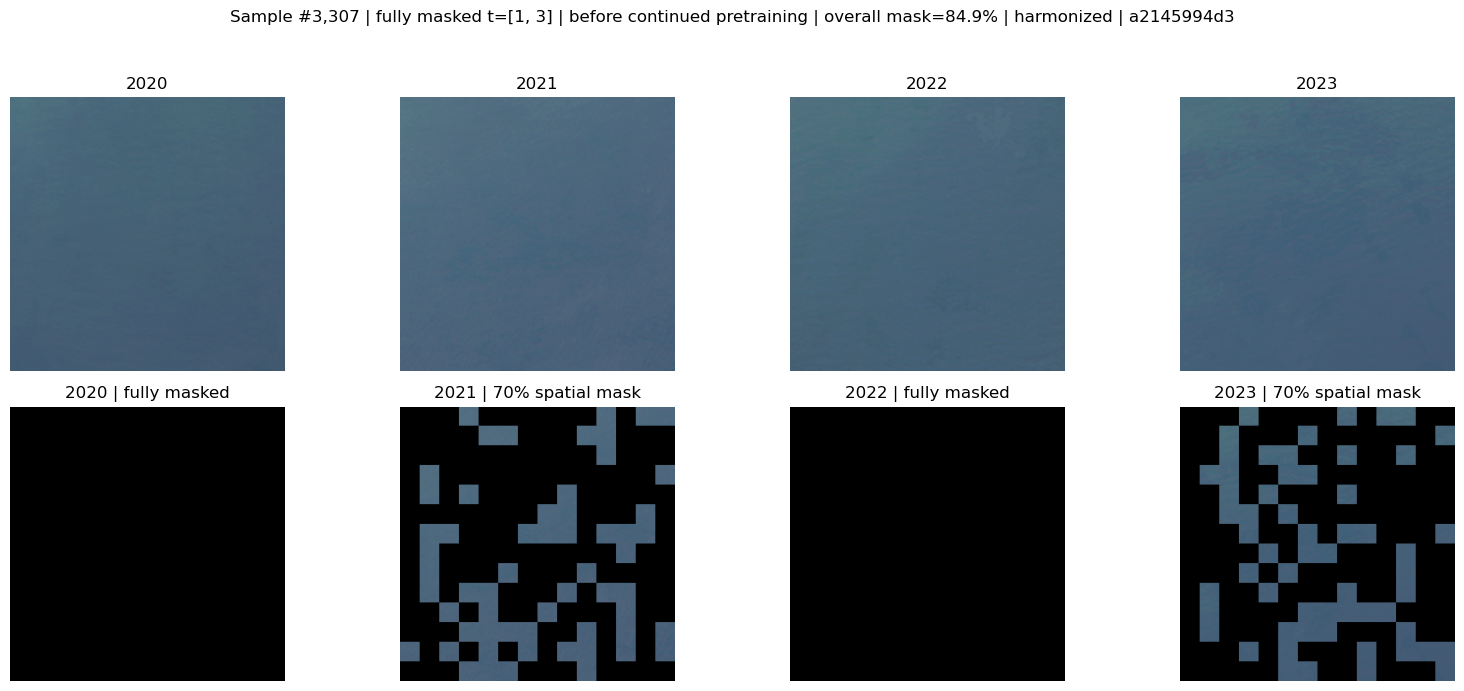

In [7]:
def denormalize_prithvi(image):
    mean = torch.as_tensor(BAND_MEAN, device=image.device, dtype=image.dtype).view(
        1, IN_CHANNELS, 1, 1, 1
    )
    std = torch.as_tensor(BAND_STD, device=image.device, dtype=image.dtype).view(
        1, IN_CHANNELS, 1, 1, 1
    )
    return image * std + mean


def token_mask_to_pixels(model, token_mask):
    patch_t, patch_h, patch_w = model.encoder.patch_embed.patch_size
    patch_values = patch_t * patch_h * patch_w * IN_CHANNELS
    expanded = token_mask.unsqueeze(-1).repeat(1, 1, patch_values)
    return model.unpatchify(expanded, image_size=(IMAGE_SIZE, IMAGE_SIZE))


def structured_token_mask(model, image, seed=None):
    token_count = model.patchify(image).shape[1]
    patches_per_frame = token_count // TIMESTEPS
    with mask_rng(seed, image.device):
        return make_temporal_spatial_mask(
            batch_size=image.shape[0],
            num_frames=TIMESTEPS,
            patches_per_frame=patches_per_frame,
            fully_masked_timesteps=FULLY_MASKED_TIMESTEPS,
            spatial_mask_ratio=SPATIAL_MASK_RATIO,
            shared_spatial_mask=SHARE_SPATIAL_MASK,
            device=image.device,
        )


def temporal_rgb(image, timestep, pixel_mask=None):
    raw = denormalize_prithvi(image)[0, :, timestep].detach().cpu().numpy()
    if pixel_mask is not None:
        mask = pixel_mask[0, 0, timestep].detach().cpu().numpy() > 0.5
        raw[:, mask] = 0.0
    rgb = raw[[2, 1, 0]].transpose(1, 2, 0)
    return np.clip(rgb / RGB_DIVISOR, 0.0, 1.0)


def visualize_mask_before_training(model, batch, sample_info, seed=None):
    image = batch["image"][:1].to(device)
    years = batch["years"][0].cpu().numpy()
    token_mask, fully_masked = structured_token_mask(
        model, image, seed
    )
    pixel_mask = token_mask_to_pixels(model, token_mask)

    figure, axes = plt.subplots(
        2, TIMESTEPS, figsize=(4 * TIMESTEPS, 7), squeeze=False
    )
    for timestep in range(TIMESTEPS):
        axes[0, timestep].imshow(temporal_rgb(image, timestep))
        axes[0, timestep].set_title(str(int(years[timestep])))
        axes[1, timestep].imshow(
            temporal_rgb(image, timestep, pixel_mask=pixel_mask)
        )
        is_fully_masked = bool(
            torch.all(
                token_mask[0].reshape(TIMESTEPS, -1)[timestep] > 0
            )
        )
        mask_label = (
            "fully masked"
            if is_fully_masked
            else f"{SPATIAL_MASK_RATIO:.0%} spatial mask"
        )
        axes[1, timestep].set_title(
            f"{int(years[timestep])} | {mask_label}"
        )
        axes[0, timestep].axis("off")
        axes[1, timestep].axis("off")
    axes[0, 0].set_ylabel("Unmasked target", fontsize=12)
    axes[1, 0].set_ylabel("Masked input", fontsize=12)
    fully_masked_numbers = (fully_masked[0].detach().cpu() + 1).tolist()
    figure.suptitle(
        f"Sample #{sample_info['sample_number']:,} | "
        f"fully masked t={fully_masked_numbers} | "
        f"before continued pretraining | overall mask={MASK_RATIO:.1%} | "
        f"{batch['variant'][0]} | {batch['patch_id'][0][:10]}"
    )
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()
    return {
        "token_mask": token_mask.cpu(),
        "pixel_mask": pixel_mask.cpu(),
        "fully_masked_timesteps": (fully_masked[0].cpu() + 1),
        "sample_info": sample_info,
    }

BEFORE_VISUALIZATION_SAMPLE_NUMBER = None  # None selects a random sample.

before_visualization_batch, before_visualization_info = load_visualization_sample(
    BEFORE_VISUALIZATION_SAMPLE_NUMBER
)
pretraining_mask_preview = visualize_mask_before_training(
    model,
    before_visualization_batch,
    before_visualization_info,
    seed=PREVIEW_MASK_SEED,
)

## Continued-pretraining loop

Loss is mean squared reconstruction error over all masked patches, including every patch in the two fully hidden years. A bounded producer thread decodes and normalizes the next batches while CUDA handles the current batch. Progress loss is copied from the GPU only every `PROGRESS_UPDATE_INTERVAL` batches. Checkpoints contain the model, optimizer, scheduler, scaler, epoch, global step, history, and masking configuration so interrupted runs can resume.

Set `RUN_TRAINING=True` in the configuration cell only after the data preview and pretrained-load audit look correct.

In [ ]:
# RUN_TRAINING is configured in the main configuration cell.

In [8]:
def constant_lr(_step):
    return 1.0


optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, constant_lr)
amp_enabled = USE_AMP and device.type == "cuda"
scaler = torch.amp.GradScaler(device.type, enabled=amp_enabled)
global_step = 0
best_val_loss = float("inf")

if resume_payload is not None:
    saved_configuration = resume_payload.get("configuration", {})
    expected_masking = {
        "fully_masked_timesteps": FULLY_MASKED_TIMESTEPS,
        "spatial_mask_ratio": SPATIAL_MASK_RATIO,
        "shared_spatial_mask": SHARE_SPATIAL_MASK,
    }
    for key, expected_value in expected_masking.items():
        if saved_configuration.get(key) != expected_value:
            raise ValueError(
                f"Resume checkpoint {key}={saved_configuration.get(key)!r}; "
                f"expected {expected_value!r}"
            )
    if "optimizer_state_dict" in resume_payload:
        optimizer.load_state_dict(resume_payload["optimizer_state_dict"])
    for parameter_group in optimizer.param_groups:
        parameter_group["lr"] = LEARNING_RATE
    if "scheduler_state_dict" in resume_payload:
        print("Skipped saved scheduler state; using constant learning rate.")
    if "scaler_state_dict" in resume_payload:
        scaler.load_state_dict(resume_payload["scaler_state_dict"])
    global_step = int(resume_payload.get("global_step", 0))
    best_val_loss = float(resume_payload.get("best_val_loss", best_val_loss))


def move_batch(batch):
    return (
        batch["image"].to(device, non_blocking=True),
        batch["temporal_coords"].to(device, non_blocking=True),
        batch["location_coords"].to(device, non_blocking=True),
    )


@torch.no_grad()
def validate_mae(model, loader, max_batches=None):
    model.eval()
    loss_sum = torch.zeros((), device=device)
    batch_count = 0
    validation_batch_count = len(loader)
    if max_batches is not None:
        validation_batch_count = min(validation_batch_count, max_batches)
    loader_iterator = iter(loader)
    cuda_devices = [torch.cuda.current_device()] if device.type == "cuda" else []
    try:
        with torch.random.fork_rng(devices=cuda_devices):
            torch.manual_seed(SEED + 100000)
            if device.type == "cuda":
                torch.cuda.manual_seed_all(SEED + 100000)
            for batch in itertools.islice(
                loader_iterator, validation_batch_count
            ):
                image, temporal_coords, location_coords = move_batch(batch)
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=amp_enabled,
                ):
                    loss, _, _ = model(
                        image,
                        temporal_coords=temporal_coords,
                        location_coords=location_coords,
                        mask_ratio=MASK_RATIO,
                    )
                loss_sum += loss.detach()
                batch_count += 1
    finally:
        if hasattr(loader_iterator, "close"):
            loader_iterator.close()
    if batch_count == 0:
        raise RuntimeError("Validation produced no batches")
    return float((loss_sum / batch_count).detach().cpu())


def save_training_checkpoint(path, epoch, model, optimizer, scheduler, scaler):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": int(epoch),
            "global_step": int(global_step),
            "best_val_loss": float(best_val_loss),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "history": dict(history),
            "configuration": {
                "mask_ratio": MASK_RATIO,
                "fully_masked_timesteps": FULLY_MASKED_TIMESTEPS,
                "spatial_mask_ratio": SPATIAL_MASK_RATIO,
                "shared_spatial_mask": SHARE_SPATIAL_MASK,
                "timesteps": TIMESTEPS,
                "patch_size": PATCH_SIZE,
                "learning_rate": LEARNING_RATE,
                "lr_schedule": globals().get("LR_SCHEDULE", "constant"),
                "weight_decay": WEIGHT_DECAY,
                "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
                "prefetch_batches": PREFETCH_BATCHES,
                "progress_update_interval": PROGRESS_UPDATE_INTERVAL,
            },
        },
        path,
    )


def train_continuous_mae(model, train_loader, val_loader):
    global global_step, best_val_loss
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

    for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):
        model.train()
        torch.manual_seed(SEED + epoch)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(SEED + epoch)
        optimizer.zero_grad(set_to_none=True)
        running_loss = torch.zeros((), device=device)
        batch_count = 0
        epoch_start = time.time()
        epoch_batch_count = len(train_loader)
        if MAX_TRAIN_BATCHES is not None:
            epoch_batch_count = min(epoch_batch_count, MAX_TRAIN_BATCHES)
        loader_iterator = iter(train_loader)
        progress = tqdm(
            itertools.islice(loader_iterator, epoch_batch_count),
            total=epoch_batch_count,
            desc=f"Epoch {epoch}/{NUM_EPOCHS}",
        )

        try:
            for batch_index, batch in enumerate(progress):
                image, temporal_coords, location_coords = move_batch(batch)
                with torch.autocast(
                    device_type=device.type,
                    dtype=torch.float16,
                    enabled=amp_enabled,
                ):
                    loss, _, _ = model(
                        image,
                        temporal_coords=temporal_coords,
                        location_coords=location_coords,
                        mask_ratio=MASK_RATIO,
                    )
                    scaled_loss = loss / GRADIENT_ACCUMULATION_STEPS
                scaler.scale(scaled_loss).backward()
                running_loss += loss.detach()
                batch_count += 1

                reached_epoch_end = batch_count == epoch_batch_count
                should_step = (
                    batch_count % GRADIENT_ACCUMULATION_STEPS == 0
                    or reached_epoch_end
                )
                if should_step:
                    scaler.unscale_(optimizer)
                    clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    scheduler.step()
                    global_step += 1

                if (
                    batch_count % PROGRESS_UPDATE_INTERVAL == 0
                    or reached_epoch_end
                ):
                    display_loss = float(
                        (running_loss / batch_count).detach().cpu()
                    )
                    progress.set_postfix(
                        loss=f"{display_loss:.4f}",
                        lr=f"{optimizer.param_groups[0]['lr']:.2e}",
                    )
        finally:
            if hasattr(loader_iterator, "close"):
                loader_iterator.close()

        train_loss = float(
            (running_loss / max(batch_count, 1)).detach().cpu()
        )
        val_loss = validate_mae(model, val_loader, MAX_VAL_BATCHES)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["learning_rate"].append(optimizer.param_groups[0]["lr"])
        history["epoch_seconds"].append(time.time() - epoch_start)

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            torch.save(
                {
                    "epoch": epoch,
                    "val_loss": val_loss,
                    "model_state_dict": model.state_dict(),
                },
                BEST_MODEL_PATH,
            )
            torch.save(model.encoder.state_dict(), BEST_ENCODER_PATH)
        if SAVE_LATEST_EVERY_EPOCH:
            save_training_checkpoint(
                LATEST_CHECKPOINT, epoch, model, optimizer, scheduler, scaler
            )

        print(
            f"Epoch {epoch:02d}: train_loss={train_loss:.6f}, "
            f"val_loss={val_loss:.6f}, best={best_val_loss:.6f}, "
            f"minutes={(time.time() - epoch_start) / 60:.1f}"
        )

    return dict(history)

In [ ]:
# The next cell starts training only when RUN_TRAINING is True.

In [ ]:
# Training-window and batch limits are configured in the main configuration cell.

In [ ]:
# Epoch count is configured in the main configuration cell.

In [15]:
RUN_TRAINING = True  # Set to True to start the training loop.

In [ ]:
if RUN_TRAINING:
    training_history = train_continuous_mae(model, train_loader, val_loader)
else:
    training_history = dict(history)
    print("Training skipped because RUN_TRAINING=False.")
    print("Set RUN_TRAINING=True after reviewing the previews and load audit.")

Epoch 1/3:  80%|███████▉  | 1216/1522 [25:11<07:20,  1.44s/it, loss=0.0319, lr=1.00e-05]

In [ ]:
if training_history.get("train_loss"):
    epochs = np.arange(1, len(training_history["train_loss"]) + 1)
    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, training_history["train_loss"], label="Train")
    axes[0].plot(epochs, training_history["val_loss"], label="Validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Masked reconstruction loss")
    axes[0].legend()
    axes[0].grid(alpha=0.25)
    axes[1].plot(epochs, training_history["learning_rate"])
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Learning rate")
    axes[1].grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No training history to plot yet.")

## Reconstruction visualization after training

The four years are columns and the requested comparison is split across three rows:

1. **Masked input**: exactly what is hidden from the encoder.
2. **Expected output**: the original unmasked reconstruction target.
3. **Prediction**: visible input patches plus MAE predictions in masked regions.

The cell works with the currently loaded model. After `RUN_TRAINING=True`, it visualizes the continued-pretrained weights. `AFTER_VISUALIZATION_SAMPLE_NUMBER=None` chooses another random image and `POST_TRAINING_MASK_SEED=None` chooses a fresh temporal-spatial mask. Use explicit sample numbers and matching integer mask seeds for an exact before/after comparison.

In [17]:
@torch.no_grad()
def reconstruct_sample(
    model, batch, sample_info, mask_ratio=MASK_RATIO, seed=None
):
    model.eval()
    image = batch["image"][:1].to(device)
    temporal_coords = batch["temporal_coords"][:1].to(device)
    location_coords = batch["location_coords"][:1].to(device)

    with mask_rng(seed, image.device):
        with torch.autocast(
            device_type=device.type, dtype=torch.float16, enabled=amp_enabled
        ):
            loss, prediction_tokens, token_mask = model(
                image,
                temporal_coords=temporal_coords,
                location_coords=location_coords,
                mask_ratio=mask_ratio,
            )

    prediction = model.unpatchify(
        prediction_tokens.float(), image_size=(IMAGE_SIZE, IMAGE_SIZE)
    )
    pixel_mask = token_mask_to_pixels(model, token_mask.float())
    masked_input = image * (1.0 - pixel_mask)
    reconstruction = image * (1.0 - pixel_mask) + prediction * pixel_mask
    mask_by_timestep = token_mask.reshape(
        token_mask.shape[0], TIMESTEPS, -1
    )
    fully_masked_timesteps = torch.nonzero(
        torch.all(mask_by_timestep[0] > 0, dim=1), as_tuple=False
    ).flatten()
    return {
        "loss": float(loss.detach().cpu()),
        "input": image,
        "masked_input": masked_input,
        "target": image,
        "raw_prediction": prediction,
        "reconstruction": reconstruction,
        "token_mask": token_mask,
        "pixel_mask": pixel_mask,
        "fully_masked_timesteps": fully_masked_timesteps,
        "years": batch["years"][0].cpu().numpy(),
        "variant": batch["variant"][0],
        "patch_id": batch["patch_id"][0],
        "sample_info": sample_info,
    }


def visualize_reconstruction_rows(result):
    figure, axes = plt.subplots(
        3, TIMESTEPS, figsize=(4 * TIMESTEPS, 10), squeeze=False
    )
    for timestep in range(TIMESTEPS):
        year = int(result["years"][timestep])
        axes[0, timestep].imshow(
            temporal_rgb(
                result["input"],
                timestep,
                pixel_mask=result["pixel_mask"],
            )
        )
        mask_label = (
            "fully masked"
            if timestep in result["fully_masked_timesteps"].tolist()
            else f"{SPATIAL_MASK_RATIO:.0%} spatial mask"
        )
        axes[0, timestep].set_title(f"{year} | {mask_label}")
        axes[1, timestep].imshow(temporal_rgb(result["target"], timestep))
        axes[1, timestep].set_title(f"{year} | expected")
        axes[2, timestep].imshow(
            temporal_rgb(result["reconstruction"], timestep)
        )
        axes[2, timestep].set_title(f"{year} | reconstructed")
        for row in range(3):
            axes[row, timestep].axis("off")

    axes[0, 0].set_ylabel("Masked input", fontsize=12)
    axes[1, 0].set_ylabel("Expected output", fontsize=12)
    axes[2, 0].set_ylabel("MAE prediction", fontsize=12)
    fully_masked_numbers = (
        result["fully_masked_timesteps"].detach().cpu() + 1
    ).tolist()
    figure.suptitle(
        f"Sample #{result['sample_info']['sample_number']:,} | "
        f"fully masked t={fully_masked_numbers} | "
        f"MAE reconstruction | mask={MASK_RATIO:.1%} | "
        f"loss={result['loss']:.6f} | "
        f"{result['variant']} | {result['patch_id'][:10]}"
    )
    plt.tight_layout(rect=(0, 0, 1, 0.95))
    plt.show()


Visualization sample #1,612/12,800 | val-00011-of-00016.tfrecord.gz | record 101


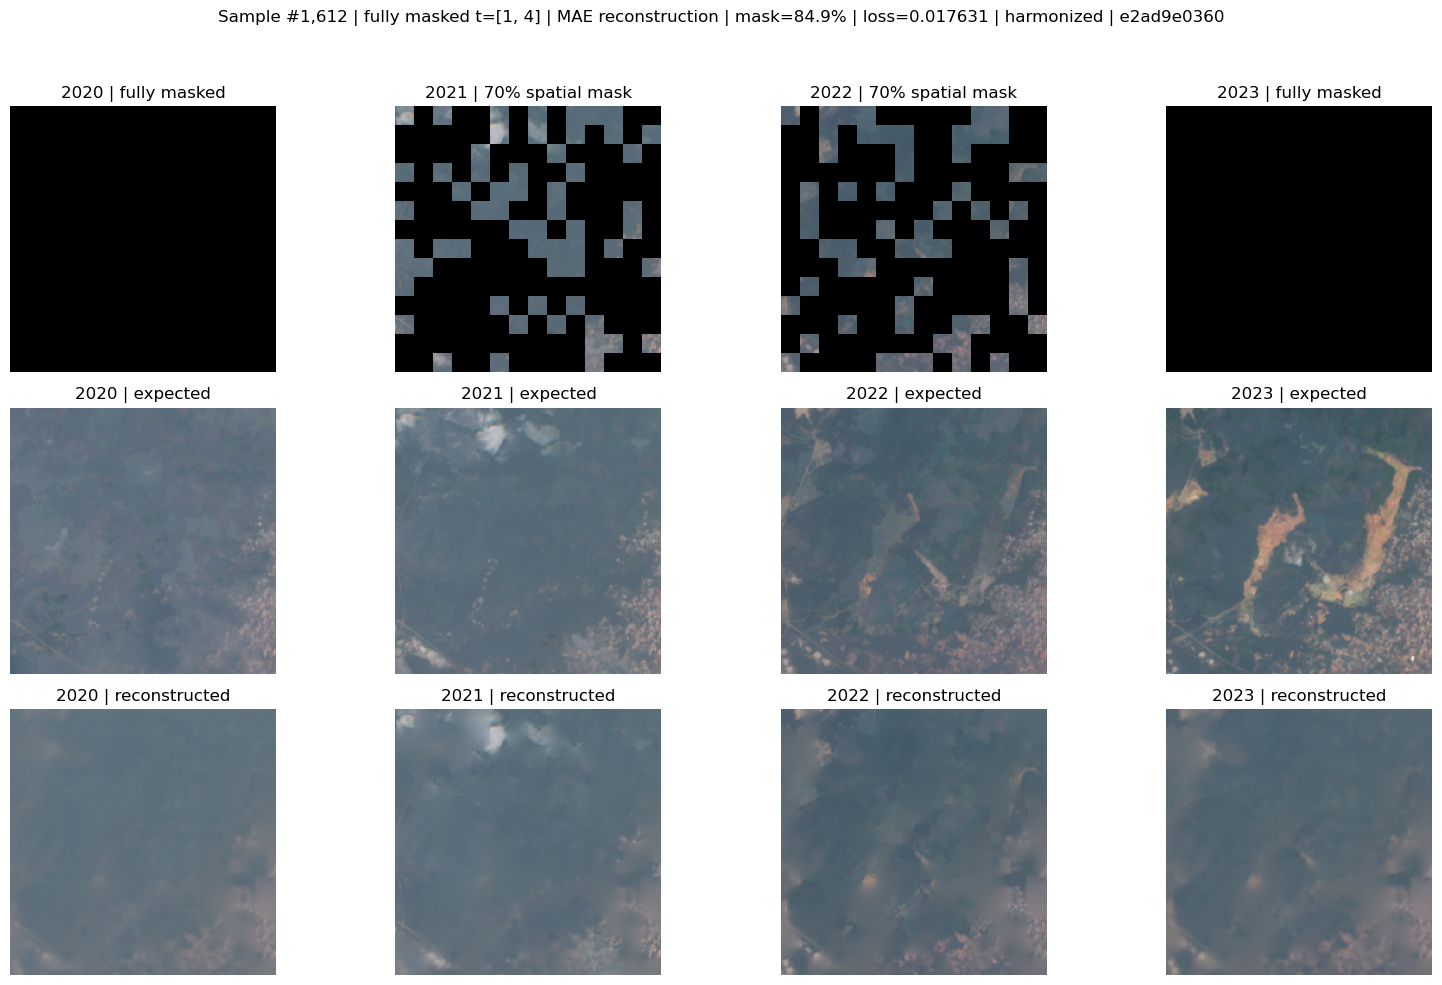

In [45]:

AFTER_VISUALIZATION_SAMPLE_NUMBER = None  # Use the same number to compare.
after_visualization_batch, after_visualization_info = load_visualization_sample(
    AFTER_VISUALIZATION_SAMPLE_NUMBER
)
post_training_result = reconstruct_sample(
    model,
    after_visualization_batch,
    after_visualization_info,
    mask_ratio=MASK_RATIO,
    seed=POST_TRAINING_MASK_SEED,
)
visualize_reconstruction_rows(post_training_result)

In [ ]:

# To revisit a specific sample, set AFTER_VISUALIZATION_SAMPLE_NUMBER
# in the cell above and rerun that cell.

In [ ]:
# To revisit a displayed sample, set AFTER_VISUALIZATION_SAMPLE_NUMBER
# in the reconstruction cell above and rerun that cell.

## Outputs and next use

- `prithvi_mae_continous3_latest.pt` is the resumable training checkpoint.
- `prithvi_mae_continous3_best.pt` contains the best complete MAE state.
- `prithvi_mae_continous3_best_encoder.pt` contains the best encoder state for downstream segmentation.

Before a long run, confirm the checkpoint coverage, inspect both visualizations, and run a short test with `MAX_TRAIN_BATCHES=10`, `MAX_VAL_BATCHES=5`, and `NUM_EPOCHS=1`. Then restore the intended values and resume from `LATEST_CHECKPOINT` if needed.